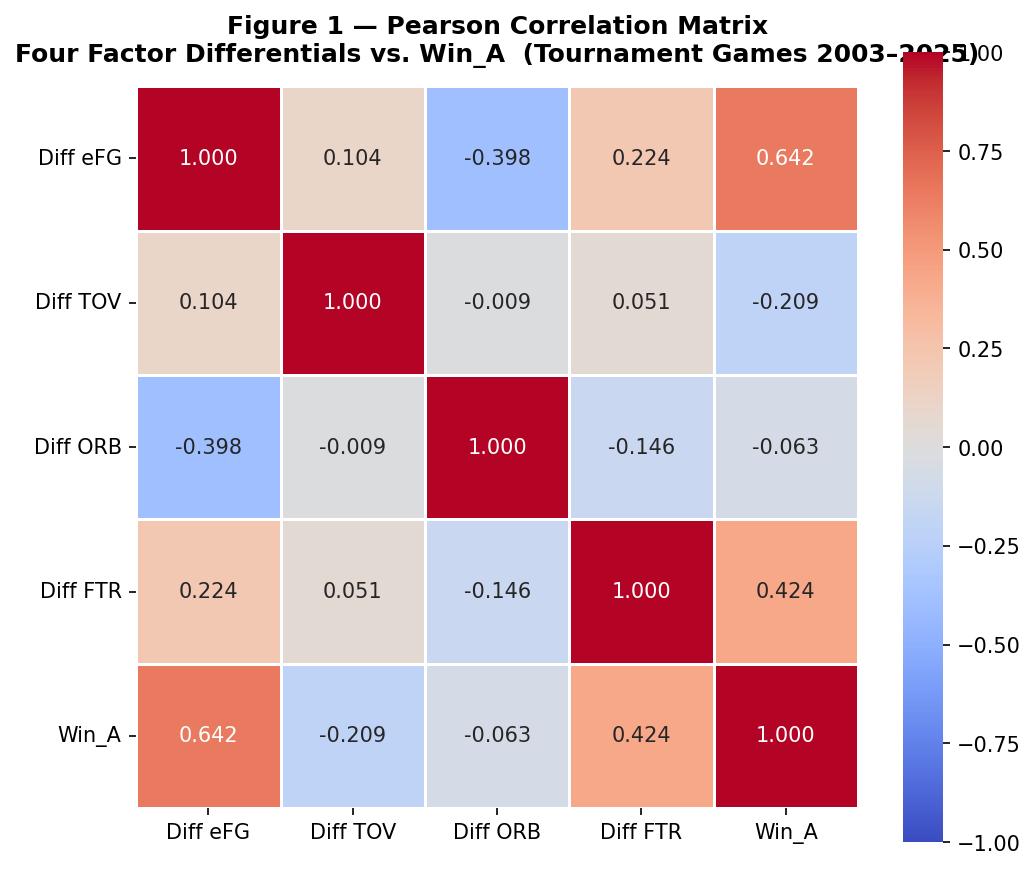


Correlations with Win_A:
DIFF_EFG    0.641650
DIFF_FTR    0.423765
Diff_TOV   -0.209218
DIFF_ORB   -0.062927


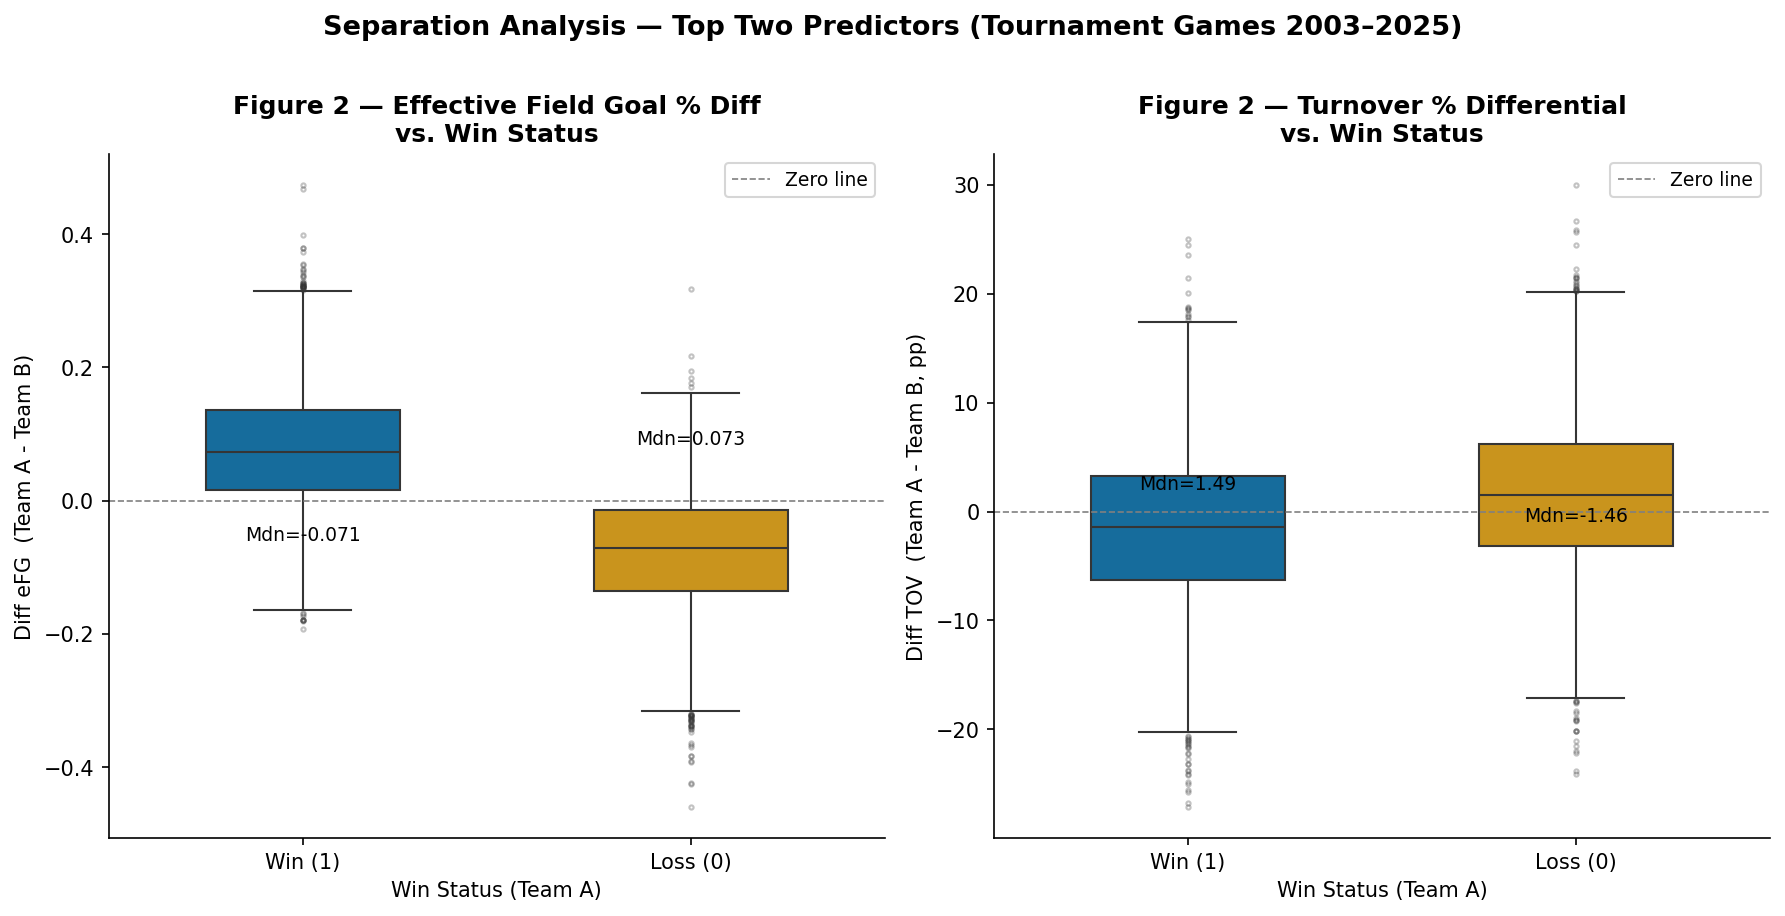

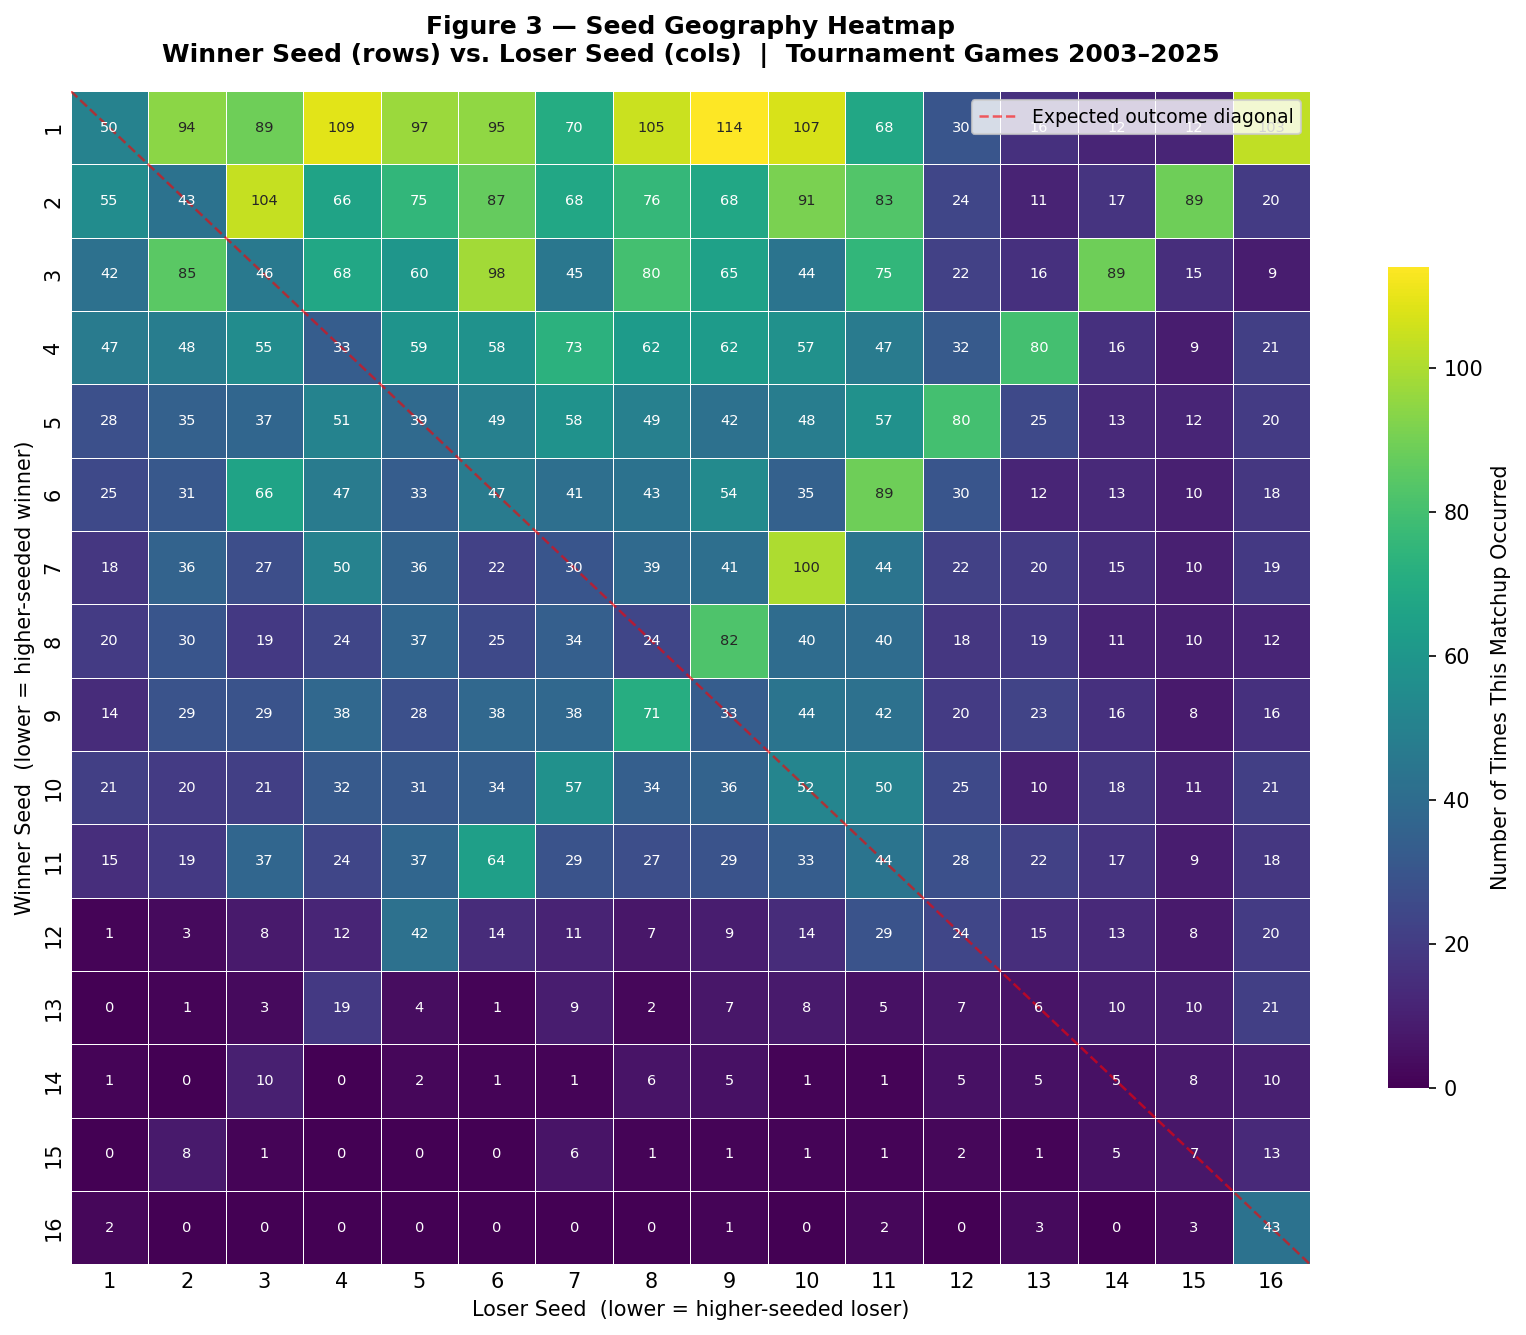


=== BIGGEST UPSET ===
Season 2018: Seed 16 beats Seed 1 (gap = 15, Round = 1)
  DIFF_EFG: +0.2202
  Diff_TOV: +7.8272
  DIFF_ORB: -0.1111
  DIFF_FTR: +0.1488


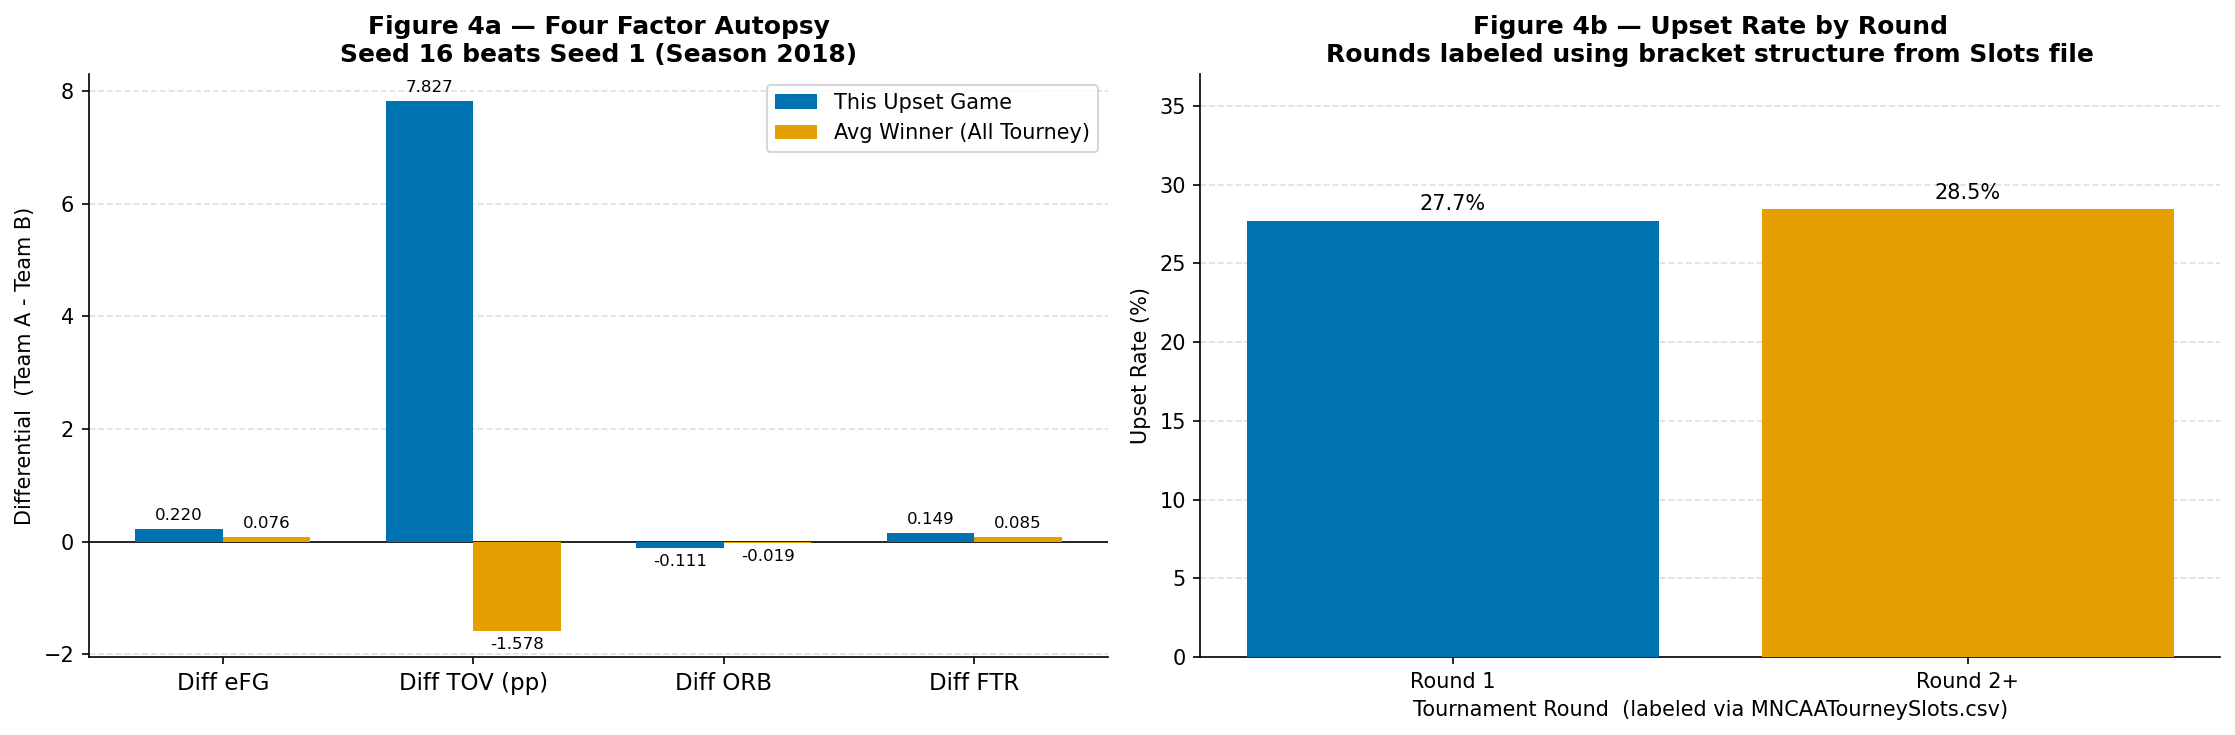

In [57]:
# ECE 3308 Project 2: 

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


# Section 1: Loads all of the data for the graphs
#
#Loads the master Analytical table and also the other tournament data
df_mat       = pd.read_csv('Master_Analytical_Table.csv')
tourneyseeds = pd.read_csv('MNCAATourneySeeds.csv')
tourneyslots = pd.read_csv('MNCAATourneySlots.csv')

#
# Section 2: Adds the global plot style
#

# Helps with the aesthetics of the graphed information
# Also helps ensure that all of the palettes are colorblind-friendly
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

#
# Section 3: Builds the seed lookup and the filter for the Tournament Games
#


#Seeds file uses strings
tourneyseeds['SeedNum'] = tourneyseeds['Seed'].str[1:3].astype(int)
seed_lookup = tourneyseeds.set_index(['Season', 'TeamID'])['SeedNum'].to_dict()

# Attaches the seeds to each team in the Mat
df_mat['SeedA'] = df_mat.apply(lambda r: seed_lookup.get((r['Season'], r['TeamA_ID']), np.nan), axis=1)
df_mat['SeedB'] = df_mat.apply(lambda r: seed_lookup.get((r['Season'], r['TeamB_ID']), np.nan), axis=1)

# Drops the regular season games and these are the rows where both teams have a seed in the tournament 
t = df_mat.dropna(subset=['SeedA', 'SeedB']).copy()
t[['SeedA', 'SeedB']] = t[['SeedA', 'SeedB']].astype(int)

#Derives the winner and losers seed from Win_A
t['WinnerSeed'] = np.where(t['Win_A'] == 1, t['SeedA'], t['SeedB'])
t['LoserSeed']  = np.where(t['Win_A'] == 1, t['SeedB'], t['SeedA'])



#
# Section 4: labels each game with its tournament round
#


# Uses slots to label each game with the tournament round
# I use the slot files to define the bracket structure. In Round 1, I use 
# Strong Seed and WeakSeed 
tourneyslots['RoundNum'] = pd.to_numeric(
    tourneyslots['Slot'].str.extract(r'^R(\d)')[0], errors='coerce')



#Isolates only round 1 slots
r1 = tourneyslots[tourneyslots['RoundNum'] == 1].copy()
r1['StrongNum'] = r1['StrongSeed'].str[1:3].astype(int)
r1['WeakNum']   = r1['WeakSeed'].str[1:3].astype(int)

# Builds the lookup set
r1_lookup = {
    (row.Season, min(row.StrongNum, row.WeakNum), max(row.StrongNum, row.WeakNum)): 1
    for row in r1.itertuples()
}

#Tags each tournament game with its round by lookup up the seed pair
t['MinSeed']    = t[['SeedA', 'SeedB']].min(axis=1)
t['MaxSeed']    = t[['SeedA', 'SeedB']].max(axis=1)
t['Round']      = t.apply(
    lambda r: r1_lookup.get((r['Season'], r['MinSeed'], r['MaxSeed']), 2), axis=1)
t['UpsetMag']   = t['WinnerSeed'] - t['LoserSeed']
t['IsUpset']    = (t['UpsetMag'] > 0).astype(int)
t['RoundLabel'] = t['Round'].map({1: 'Round 1', 2: 'Round 2+'})


#
# Part A: Correlation Matrix
#
# Computes the correlation between every pair of features and Win_A.
# When the value is close to +1 it means that the feature rises with the win and 
# if it close to -1 it means that it will fall with wins. if its close to 0 then 
# it means that it has no linear relationship

#Creates the five clumns that we care about
FEATURES = ['DIFF_EFG', 'Diff_TOV', 'DIFF_ORB', 'DIFF_FTR', 'Win_A']
LABELS   = ['Diff eFG', 'Diff TOV', 'Diff ORB', 'Diff FTR', 'Win_A']


# Comuputes the correlation matrix
corr = t[FEATURES].corr()

#Ensures that the matrix is color friendly
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', square=True,
            xticklabels=LABELS, yticklabels=LABELS, annot_kws={'size': 10}, ax=ax)
ax.set_title('Figure 1 — Pearson Correlation Matrix\n'
             'Four Factor Differentials vs. Win_A  (Tournament Games 2003–2025)',
             fontweight='bold', pad=12)
ax.tick_params(rotation=0)
plt.tight_layout()
plt.savefig('fig1_correlation_matrix.png', bbox_inches='tight')
plt.show()

win_corr = corr['Win_A'].drop('Win_A').sort_values(key=abs, ascending=False)
print(f"\nCorrelations with Win_A:\n{win_corr.to_string()}")


#
# Part B: Separation Box Plots
#
# The top two predictors Diff eFG, and Diff Tov are plotted and distributed by
# each feature of split by Win_A. If there is an instance that truly seperates
# the winners and losers, the two boxes will sit on opposite sides of the zero line.


# The subest for the two features and the outcomes
plot_df = t[['DIFF_EFG', 'Diff_TOV', 'Win_A']].copy()
plot_df['Win_A'] = plot_df['Win_A'].map({0: 'Loss (0)', 1: 'Win (1)'})

# Designed to help with being color-blind friendly
PALETTE = {'Loss (0)': '#E69F00', 'Win (1)': '#0072B2'}   

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Loops ovr both simultaneously and ensures that theres no duplicates
for ax, col, ylabel, title_suffix, offset, fmt in zip(
    axes,
    ['DIFF_EFG',                    'Diff_TOV'],
    ['Diff eFG  (Team A - Team B)', 'Diff TOV  (Team A - Team B, pp)'],
    ['Effective Field Goal % Diff', 'Turnover % Differential'],
    [0.005,                          0.15],
    ['.3f',                          '.2f'],
):
    sns.boxplot(data=plot_df, x='Win_A', y=col,
                hue='Win_A', palette=PALETTE, width=0.5, legend=False,
                flierprops=dict(marker='o', markersize=2, alpha=0.3), ax=ax)

    # Creates the zero reference line to help show the directions
    ax.axhline(0, color='grey', linewidth=0.8, linestyle='--', label='Zero line')
    ax.set_title(f'Figure 2 — {title_suffix}\nvs. Win Status', fontweight='bold')
    ax.set_xlabel('Win Status (Team A)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    for i, cat in enumerate(['Loss (0)', 'Win (1)']):
        med = plot_df.loc[plot_df['Win_A'] == cat, col].median()
        ax.text(i, med + offset, f'Mdn={med:{fmt}}', ha='center', va='bottom', fontsize=9)

fig.suptitle('Separation Analysis — Top Two Predictors (Tournament Games 2003–2025)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig2_boxplots.png', bbox_inches='tight')
plt.show()


#
# Part C: Seed Geography Heatmap
#
# Counts how many times each WinnerSeed and Loserseed pair has occured in all of th
# tournament seasons and will give a 16x16 matrix



#groups the size count occurences and reindes forces all seeds 1-16
heatmap_pivot = (
    t.groupby(['WinnerSeed', 'LoserSeed']).size()
     .unstack(fill_value=0)
     .reindex(index=range(1, 17), columns=range(1, 17), fill_value=0)
)


fig, ax = plt.subplots(figsize=(11, 9))

#Ensures that it is colorblind friendly
sns.heatmap(heatmap_pivot, cmap='viridis', linewidths=0.3, linecolor='white',
            annot=True, fmt='.0f', annot_kws={'size': 7},
            cbar_kws={'label': 'Number of Times This Matchup Occurred', 'shrink': 0.7},
            ax=ax)
ax.set_title('Figure 3 — Seed Geography Heatmap\n'
             'Winner Seed (rows) vs. Loser Seed (cols)  |  Tournament Games 2003–2025',
             fontweight='bold', pad=14)
ax.set_xlabel('Loser Seed  (lower = higher-seeded loser)')
ax.set_ylabel('Winner Seed  (lower = higher-seeded winner)')
ax.tick_params(length=0)

#Draws the expected outcome diagonal 
ax.plot([0, 16], [0, 16], color='red', linewidth=1.2, linestyle='--',
        alpha=0.6, label='Expected outcome diagonal')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('fig3_seed_heatmap.png', bbox_inches='tight')
plt.show()


# Part D: Upset Autopsy
# Finds the single largest upset in the dataset by the seed gap, then examines 
# the four factor differentials vs. the tournament average winning game.
# Then the second panel uses the round labels to determine if upsets are more
# common in Round 1 vs. later rounds


# Filters the biggest upset
biggest = t[t['UpsetMag'] > 0].nlargest(1, 'UpsetMag').iloc[0]


# Prints the biggest upset
print(f"\n=== BIGGEST UPSET ===")
print(f"Season {int(biggest['Season'])}: "
      f"Seed {int(biggest['WinnerSeed'])} beats Seed {int(biggest['LoserSeed'])} "
      f"(gap = {int(biggest['UpsetMag'])}, Round = {int(biggest['Round'])})")
for f in ['DIFF_EFG', 'Diff_TOV', 'DIFF_ORB', 'DIFF_FTR']:
    print(f"  {f}: {biggest[f]:+.4f}")

#Column names and display labels for the Four Factors
FACTORS = ['DIFF_EFG', 'Diff_TOV', 'DIFF_ORB', 'DIFF_FTR']
FLABELS = ['Diff eFG', 'Diff TOV (pp)', 'Diff ORB', 'Diff FTR']
upset_vals = [biggest[f] for f in FACTORS]
avg_vals   = [t.loc[t['Win_A'] == biggest['Win_A'], f].mean() for f in FACTORS]

x, width = np.arange(4), 0.35
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left panel: Four Factors bar chart for the biggest upset
ax = axes[0]
b1 = ax.bar(x - width/2, upset_vals, width, color='#0072B2', label='This Upset Game', zorder=3)
b2 = ax.bar(x + width/2, avg_vals,   width, color='#E69F00', label='Avg Winner (All Tourney)', zorder=3)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(FLABELS, fontsize=11)
ax.set_ylabel('Differential  (Team A - Team B)')
ax.set_title(f'Figure 4a — Four Factor Autopsy\n'
             f'Seed {int(biggest["WinnerSeed"])} beats Seed {int(biggest["LoserSeed"])} '
             f'(Season {int(biggest["Season"])})',
             fontweight='bold')
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.legend(fontsize=10)

# Right panel: Upset rate by round and uses RoundLabel derived from tourneyslots
ax = axes[1]

# Computes the mean of IsUpset within each Roundlabel group.
upset_by_round = t.groupby('RoundLabel')['IsUpset'].mean() * 100
bars = ax.bar(upset_by_round.index, upset_by_round.values,
              color=['#0072B2', '#E69F00'], zorder=3)

#Labels each bar with the exact percentage value
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax.set_ylabel('Upset Rate (%)')
ax.set_xlabel('Tournament Round  (labeled via MNCAATourneySlots.csv)')
ax.set_title('Figure 4b — Upset Rate by Round\n'
             'Rounds labeled using bracket structure from Slots file',
             fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
ax.set_ylim(0, upset_by_round.max() * 1.3)

plt.tight_layout()
plt.savefig('fig4_upset_autopsy.png', bbox_inches='tight')
plt.show()